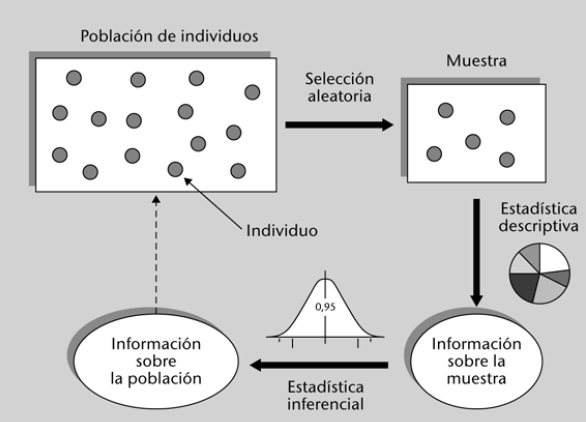

#Probabilidad y estadística 2025

# Visualización de datos con gráficos simples

En esta notebook recorremos distintos tipos básicos de grafícos que pueden utilizarse en el análisis de datos, con aplicaciones prácticas. Nos centraremos no sólo el código para generarlos, sino también en algunos pequeños trucos para lograr gráficos más legibles.



Es importante recordar que, a pesar de que esta notebook utiliza los datos para ejemplificar los gráficos, en la aplicación real de la ciencia de datos ocurre lo contrario. Debemos pensar primero en la pregunta a responder, y luego diseñar la visualización.

Esto incluye:

1. Encontrar el gráfico adecuado para los datos
2. Agrupar los datos de manera que resalten el patrón que ayuda a responder la pregunta inicial.
3. Encontrar los encodings visuales más efectivos para comunicar este patrón (aunque no vamos a hablar tanto de eso en esta notebook).

# 1.Tablas

Las tablas son muchas veces dejadas de lado en las visualizaciones, pero son una de las formas de representación más poderosa. Usualmente partimos de una tabla para generar visualizaciones más complejas, pero esto no significa que generar buenas tablas no sea útil en el proceso de comunicación.

* Muestran cantidades exactas
* Representan cualquier tipo de datos
* Son de acceso universal
* Son fáciles de crear
* Permiten comprar muchas variables

Lo primero que tenemos que hacer para comenzar a enteder el dataset es ver los valores como una tabla, para indentificar la información en cada una de las columnas.

Empecemos levantando una tabla creada en excel

##1.1 ¿Cómo leer datos desde pandas?

En esta primera notebook, aprendemos cómo cargar un conjunto de datos utilizando pandas y cómo ver su contenido.

In [139]:
import io
import pandas
import seaborn
import numpy
import matplotlib.pyplot as plt


pandas.options.display.float_format = '{:.2f}'.format

print(seaborn.__version__)
BLUE = '#35A7FF'
RED = '#FF5964'
GREEN = '#6BF178'
YELLOW = '#FFE74C'
# Con esto hacemos los gráficos más grandes, adecuados para las presentaciones.
#seaborn.set_context(context='talk', font_scale=1.2)

0.13.2


En el aula virtual tienen un conjunto de datos que tienen que bajar al disco de la computadora donde estan trabajando `Dataset_2025.xlsx`

Luego, pueden levantar el archivo desde su disco en la computadora personal y subirlo al temporario con las siguientes sentencias

In [185]:
from google.colab import files
uploaded = files.upload()

Saving Dataset_2025.xlsx to Dataset_2025 (2).xlsx


Una vez subido el archivo, éste está disponible en la variable `uploaded`, que es un diccionario. Casi siempre, la clave que estamos buscando es el nombre del archivo que acabamos de subir, pero podría no ser el caso. Para estar seguro, vamos a listar los archivos que se subieron.

In [186]:
print(uploaded.keys())

dict_keys(['Dataset_2025 (2).xlsx'])


Una vez que tenemos la clave correspondiente, obtenemos el contenido del archivo. Como es un archivo excel usamos read_excel de pandas

In [187]:
df_1 = pandas.read_excel('Dataset_2025 (2).xlsx')

Con esta operación, hemos creado un DataFrame de pandas en base al archivo de respuestas. Un DataFrame no es más que una tabla sobre la cual podemos aplicar un montón de operaciones similares a las de Excel o a las SQL. En esta notebook no pretendemos hacer un tutorial de pandas, el Internet está lleno de ellos, pero sí iremos explicando cómo implementar determinadas operaciones necesarias para el análisis de este conjunto de datos.



El tamaño del dataset es

In [188]:
print(df_1.shape)

(167, 7)


In [128]:
df_1[:10]

,Marca temporal,¿Con qué género te identificás?,¿Qué edad tenés?,¿De qué signo sos?,¿A qué te dedicás?,¿Cuánto creés que gana por mes un programador (con dos o menos años de experiencia) en la industria argentina?,¿Cuánto creés que gana por mes un programador (con tres o más años de experiencia) en la industria argentina?
0,2020-03-31 17:10:01.090,Mujer,27,Tauro,Programadora,40000,80000
1,2020-05-12 15:19:13.568,Mujer,40,Acuario,Docente investigadora,50000,90000
2,2020-05-13 13:43:48.132,Hombre,22,Géminis,Estudiante de Astronomía,25000,60000
3,2020-05-13 18:12:04.173,Mujer,23,Cáncer,profesora,32000,50000
4,2020-05-14 16:30:09.247,Hombre,33,Capricornio,Docente investigador,60000,80000
5,2020-05-14 19:46:31.652,Hombre,29,Sagitario,Ingenieria de circuitos integrados,55000,75000
6,2020-05-14 19:46:56.941,Hombre,36,Libra,Emprendedor,50000,80000
7,2020-05-14 19:49:24.284,Hombre,28,Cáncer,Diseñador de circuitos digitales,50000,60000
8,2020-05-14 19:53:11.935,Hombre,39,Escorpio,programador,100000,150000
9,2020-05-14 19:54:35.203,Hombre,28,Géminis,Estudiante de Sociología,40000,60000


Saco la marca temporal, que no me interesa.

In [189]:
df = df_1.drop('Marca temporal', axis=1)

Veamos qué tiene adentro el DataFrame `df`.

In [130]:
df[:10]

,¿Con qué género te identificás?,¿Qué edad tenés?,¿De qué signo sos?,¿A qué te dedicás?,¿Cuánto creés que gana por mes un programador (con dos o menos años de experiencia) en la industria argentina?,¿Cuánto creés que gana por mes un programador (con tres o más años de experiencia) en la industria argentina?
0,Mujer,27,Tauro,Programadora,40000,80000
1,Mujer,40,Acuario,Docente investigadora,50000,90000
2,Hombre,22,Géminis,Estudiante de Astronomía,25000,60000
3,Mujer,23,Cáncer,profesora,32000,50000
4,Hombre,33,Capricornio,Docente investigador,60000,80000
5,Hombre,29,Sagitario,Ingenieria de circuitos integrados,55000,75000
6,Hombre,36,Libra,Emprendedor,50000,80000
7,Hombre,28,Cáncer,Diseñador de circuitos digitales,50000,60000
8,Hombre,39,Escorpio,programador,100000,150000
9,Hombre,28,Géminis,Estudiante de Sociología,40000,60000


## 1.2 Variables


Para trabajar más cómodamente, renombraremos las columnas de DataFrame. Tengan cuidado de que el orden de los nombres nuevos se corresponda con el contenido de cada columna.

In [190]:
df.columns = ['gender', 'age', 'zodiac_sign', 'profession', 'junior_programmer_salary', 'senior_programmer_salary']

Las medidas resumen de las variables continuas del dataset son

In [191]:
df.describe()

,age,junior_programmer_salary,senior_programmer_salary
count,167.00,167.00,167.00
mean,33.40,52922.56,94270.26
std,10.62,21027.06,96616.11
min,9.00,3.00,4.00
25%,26.00,40000.00,60000.00
50%,31.00,50000.00,80000.00
75%,38.00,60000.00,90000.00
max,99.00,150000.00,900000.00


También pandas nos permite otras operaciones simples de estadística descriptiva. En la siguiente línea, estamos filtrando las filas que se identifican como *Hombres* y describiendo mediante estadísticos muestrales la variable respuesta a la pregunta *¿Cuánto creés que gana por mes un programador (con dos o menos años de experiencia) en la industria argentina?*

In [133]:
# Estadisticos descriptivos de la distribución de la variable "Cuánto creés que gana por
#mes un programador (con dos o menos años de experiencia) en la industria argentina?"
# solo en los registros donde "Me identifico" tiene el valor Hombre

df[df.gender == 'Hombre'].junior_programmer_salary.describe()

,junior_programmer_salary
count,105.00
mean,53686.33
std,20356.36
min,65.00
25%,45000.00
50%,50000.00
75%,60000.00
max,150000.00


Ahora, estamos filtrando las filas que se identifican como Hombres y describiendo mediante estadísticos muestrales la variable respuesta a la pregunta ¿Cuánto creés que gana por mes un programador (con tres o más años de experiencia) en la industria argentina?

In [100]:
df[df.gender == 'Hombre'].senior_programmer_salary.describe()

,senior_programmer_salary
count,105.00
mean,100267.90
std,116993.86
min,130.00
25%,70000.00
50%,80000.00
75%,95000.00
max,900000.00


Con un cálculo grosero, quien ganaba 50 mil pesos en el 2020 ahora gana 1 millon sescientos si se calcula el aumento por inflación **https://chequeado.com/inflacionacumulada/**


##1.3  Tipos de datos vs variables aleatorias





En base a la definición de variable aleatoria que vimos en el teórico, podemos hablar de que cada columna de nuestro dataset es un **variable aleatoria**, y que su valor en cada respuesta es una **realización** de dicha variable. Pero, ¿qué tipo tienen esas variables?

Tenemos que distinguir dos conceptos con el mismo nombre y significado similar, pero que no son iguales:
 - **tipo de la variable aleatoria** es el tipo teórico que tienen nuestros datos.
 - **tipo de datos** es un concepto de programación que indica en qué formato se representa la información.




### Rango y valores posibles

Siempre es útil saber qué valores puede tomar una variable para entender qué tipo tiene. Sin embargo, si sospechamos que una variable es continua, no tiene sentido listar todos sus valores posibles. En ese caso, nos conviene mostrar sólo el rango, o tomar una pequeña muestra. Veamos algunos ejemplos:

In [192]:
df.gender.unique()  # Listar todos los valores posibles

array(['Mujer', 'Hombre', 'Prefiero no decirlo', 'Otro'], dtype=object)

In [193]:
df.age.max(), df.age.min()  # Variable numérica, calculamos algunos estadísticos (recordemos que esto tambien lo hace df.age.describe())

(99, 9)

In [103]:
df.age.describe()

,age
count,167.00
mean,33.40
std,10.62
min,9.00
25%,26.00
50%,31.00
75%,38.00
max,99.00


In [104]:
df.junior_programmer_salary.sample(n=10)  # El método sample(n=10) en pandas toma una muestra aleatoria de 10 filas
# de la columna junior_programmer_salary.
#Por defecto, muestrea sin reemplazo, lo que significa que cada fila solo se puede seleccionar una vez.

,junior_programmer_salary
44,45000
73,35000
27,50000
153,50000
59,90000
63,30000
150,40000
21,55000
132,60000
60,75000


In [105]:
df.profession.unique()#[:10]

array(['Programadora', 'Docente investigadora',
       'Estudiante de Astronomía', 'profesora', 'Docente investigador',
       'Ingenieria de circuitos integrados', 'Emprendedor',
       'Diseñador de circuitos digitales', 'programador',
       'Estudiante de Sociología', 'investigador-docente',
       'Analista de Datos', 'Economista', 'Programador',
       'Estudiante de ingeniería', 'economista', 'Empleado', 'Gestión',
       'docente', 'Varios', 'programadora, artista', 'calidad', 'gestion',
       'Estudiante de matemática', 'Químico', 'Ing. Quimica',
       'comerciante', 'investigador', 'estudiante', 'Astrónoma',
       'Asesor Tecno, Director de Proyecto Industria 4.0',
       'Estudiante de doctorado en física', 'Ingeniero', 'Contador',
       'Locutora', 'Developer', 'Electricista', 'Traductor',
       'licenciado en física', 'Ingeniero de Software', 'Veterinaria',
       'estudiante de computación', 'Software Engineer', 'Data Analytics',
       'Contadora', 'estudiante de in

###Tipos de datos

Ahora pasemos al tipo de datos. Podemos saber con Pandas cómo está guardando la información de cada columna:

In [106]:
df.dtypes

,0
timestamp,datetime64[ns]
gender,object
age,int64
zodiac_sign,object
profession,object
junior_programmer_salary,int64
senior_programmer_salary,int64


En este caso, el tipo `object` hace referencia a un string, pero también podría ser una fecha, una lista, o cualquier cosa más compleja que un número. El tipo de datos no siempre se correlaciona con el tipo de la variable. Por ejemplo, si guardamos un puntaje de satisfacción del 1 al 5, aunque usemos números, esa variable es conceptualmente categórica ordinal y no numérica.

##1.4 Probabilidad

Antes de hablar de probabilidad condicional entre dos variables, tenemos que encontrar un método para calcular la probabilidad de cada evento por separado. En el teórico vimos que si cada una de nuestros eventos es independiente e idénticamente distribuido, es decir, que $P(\{a_i\})=1/k$, entonces la probabilidad de un conjunto $A \subset \Omega$ es la proporción de $A$.

$$P(\{a_i\})=1/k \implies P(A)=|A|/|\Omega|=|A|/k$$

Calculemos entonces la probabilidad del evento *gender=Mujer*. Nuestro $\Omega$ son todas las respuestas del dataset, cada $a_i$ es una variable que representa una respuesta, y el conjunto $A$ son las respuestas en la que la columna gender tiene el valor "Mujer".

In [111]:
p_mujer = len(df[df.gender == 'Mujer']) / len(df)
p_mujer

0.2994011976047904

Para calcular la frecuencia relativa en lugar de la frecuencia de todos las respuestas posibles para cada columna de una forma más sencilla con la operación value_counts de pandas.

In [194]:
data = df['gender'].value_counts(normalize=True).reset_index()
data

,gender,proportion
0,Hombre,0.63
1,Mujer,0.30
2,Prefiero no decirlo,0.05
3,Otro,0.02


### Probabilidad condicional

Ahora podemos pasar a hablar de la probabilidad condicional. La definimos como

$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

Esto es equivalente a:

$$P(A|B) = \frac{|A \cap B|}{|B|}$$

*italicized text*


Calculemos la probabilidad de que una respuesta tenga *gender=Mujer* dado que sabemos que tiene *zodiac_sign=Aries*

In [195]:
count_mujer_dado_aries = len(df[(df.gender == 'Mujer') & (df.zodiac_sign == 'Aries')])/len(df[df.zodiac_sign == 'Aries'])

print("\nProbabilidad de que la persona seleccionada sea Mujer dado que sabemos que es ariana:")

print(f"{count_mujer_dado_aries:.3f}")



Probabilidad de que la persona seleccionada sea Mujer dado que sabemos que es ariana:
0.471


### Independencia

Ahora, para saber si dos conjuntos son independientes, tenemos que comprobar si $P(A|B) = P(A)$ ó $P(A\cap B) = P(A)*P(B)$.



Calculemos si los conjuntos de respuestas con *gender=Mujer* y *zodiac_sign=Aries* son independientes o no, utilizando ambos métodos.

In [196]:
#P(A∩B)
count_mujer_dado_aries = len(df[(df.gender == 'Mujer') & (df.zodiac_sign == 'Aries')])/len(df[df.zodiac_sign == 'Aries'])
print(f"Probabilidad de que la persona seleccionada sea una Mujer sea Aries: {count_mujer_dado_aries:.3f}")
#P(A)
print("\nProbabilidad de que la persona seleccionada sea Mujer:")
p_mujer = len(df[df.gender == 'Mujer']) / len(df)
print(f"{p_mujer:.3f}")
#P(B)
print("\nProbabilidad de que la persona sea seleccionada sea Aries:")
p_aries = len(df[df.zodiac_sign == 'Aries']) / len(df)
print(f"{p_aries:.3f}")

if ((p_mujer * p_aries) == count_mujer_dado_aries):
    print("\nLos conjuntos son independientes")
else :
    print("\nLos conjuntos no son independientes")
    pa_pb = p_mujer * p_aries
    print(f"{pa_pb:.3f} Es distinto a {count_mujer_dado_aries:.3f}")

Probabilidad de que la persona seleccionada sea una Mujer sea Aries: 0.471

Probabilidad de que la persona seleccionada sea Mujer:
0.299

Probabilidad de que la persona sea seleccionada sea Aries:
0.102

Los conjuntos no son independientes
0.030 Es distinto a 0.471


#2.Gráficos de distribuciones


## 2.1 Funciones de masa puntual de variables categóricas






###Gráficos usando pandas

<Axes: ylabel='gender'>

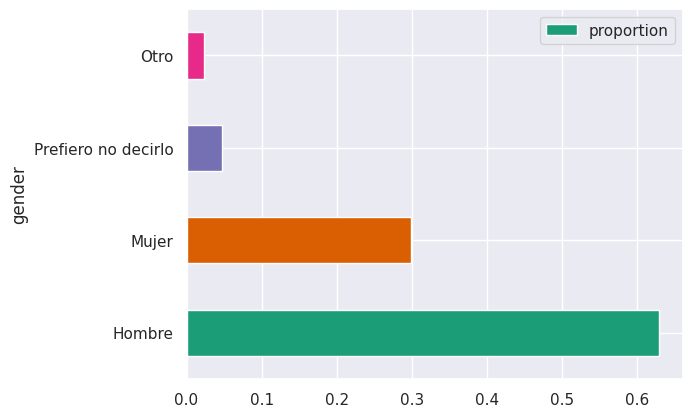

In [145]:
data = df['gender'].value_counts(normalize=True).reset_index()
data.plot(x='gender', y='proportion', kind='barh', color=seaborn.palettes.mpl_palette('Dark2'))

##2.2 Gráficos de Barras usando Seaborn


Podemos comparar visualmente la frecuencia de distintos conjuntos de datos de manera muy fácil usando los *gráficos de barras*. Pueden usarse para aproximar la distribución de una sola variable, o para estudiar el comportamiento de una variable con respecto a una o mas variables.



###Countplot

<Axes: xlabel='count', ylabel='gender'>

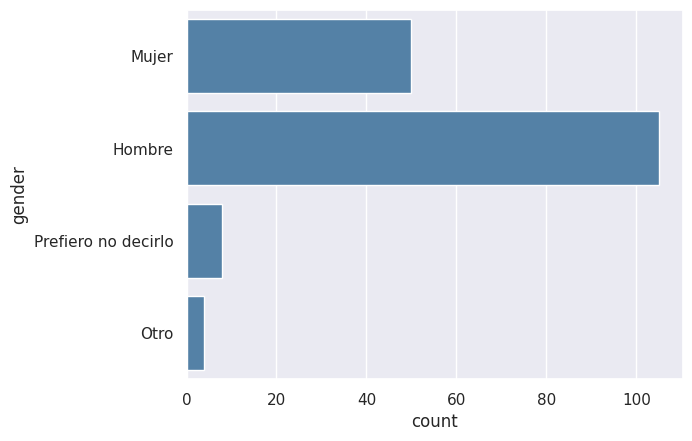

In [140]:
seaborn.countplot(df.gender, color='steelblue')

<Axes: xlabel='gender', ylabel='count'>

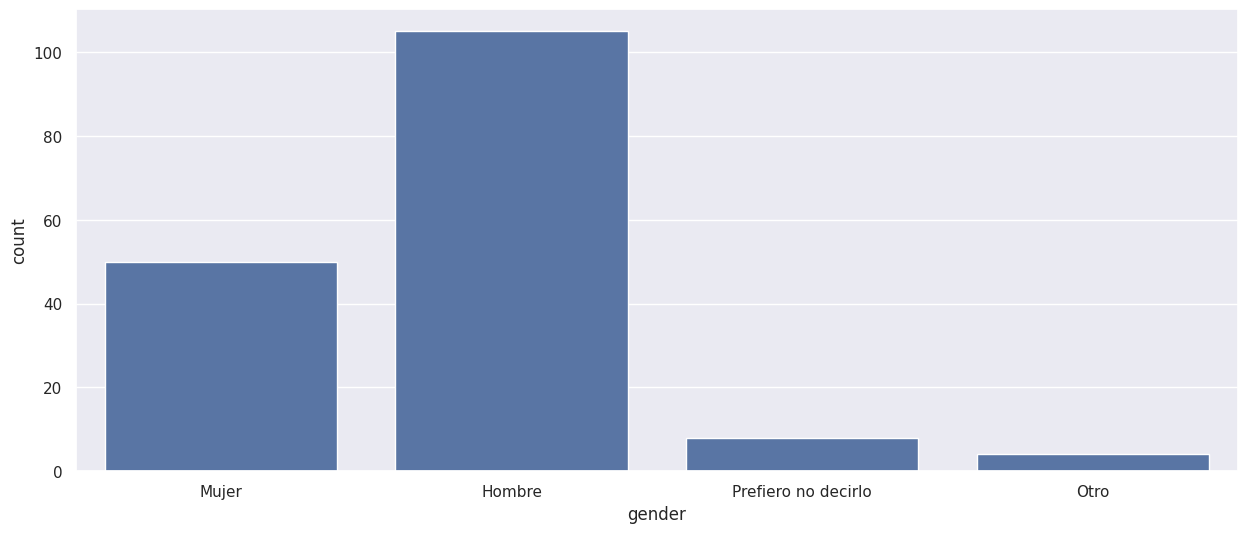

In [150]:
plt.figure(figsize=(15,6))

seaborn.countplot(data=df, x='gender')

###Barplot

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123],
 [Text(0, 0, 'Programador'),
  Text(1, 0, 'programador'),
  Text(2, 0, 'Economista'),
  Text(3, 0, 'estudiante'),
  Text(4, 0, 'Analista de Datos'),
  Text(5, 0, 'investigador'),
  Text(6, 0, 'profesora'),
  Text(7, 0, 'docente'),
  Text(8, 

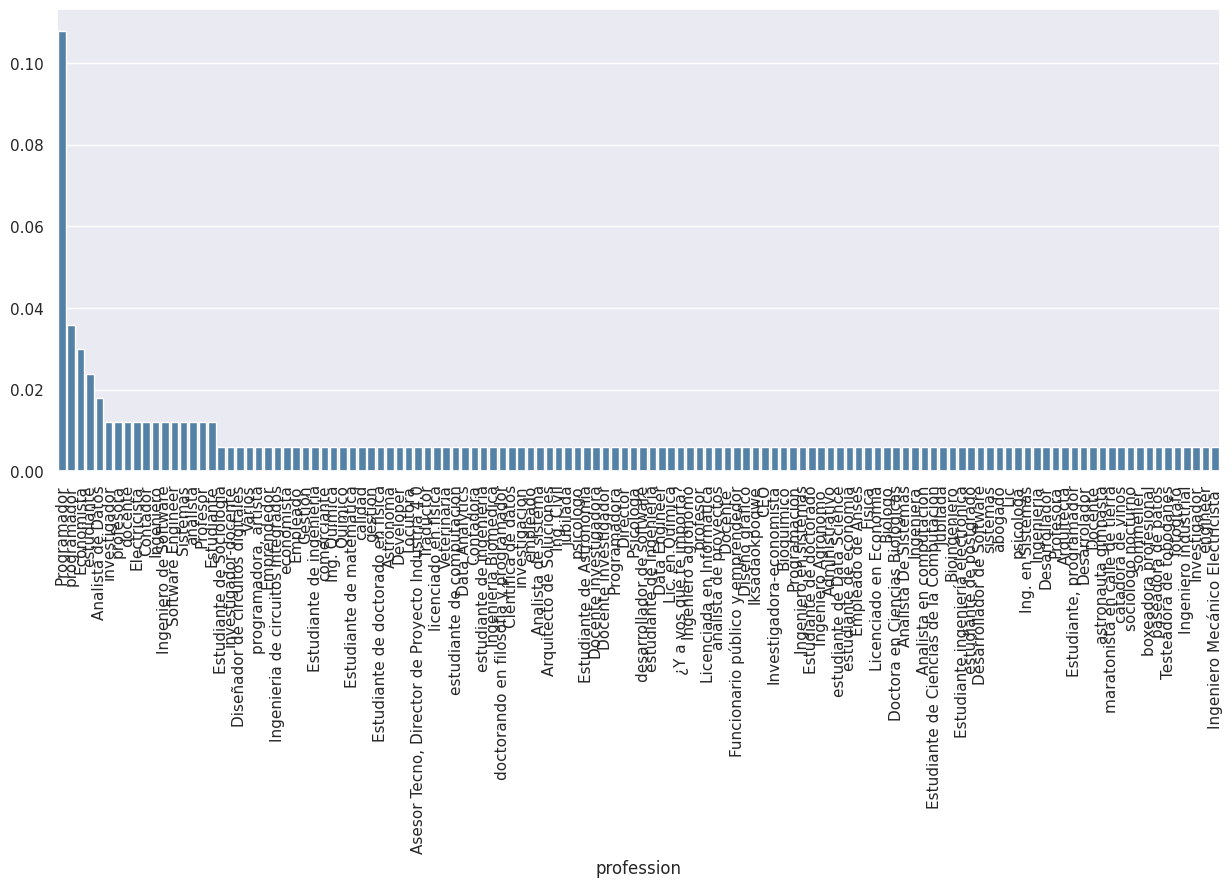

In [142]:
data = df.profession.value_counts(normalize=True)
seaborn.set_theme(style="darkgrid")
plt.figure(figsize=(15, 6))
seaborn.barplot(x=data.index, y=data.values, color='steelblue')
plt.xticks(rotation=90)

Pongamos las cosas en proporción. Muchas veces cambiar los ejes de los gráficos produce resultados muy distintos

(0.0, 0.15)

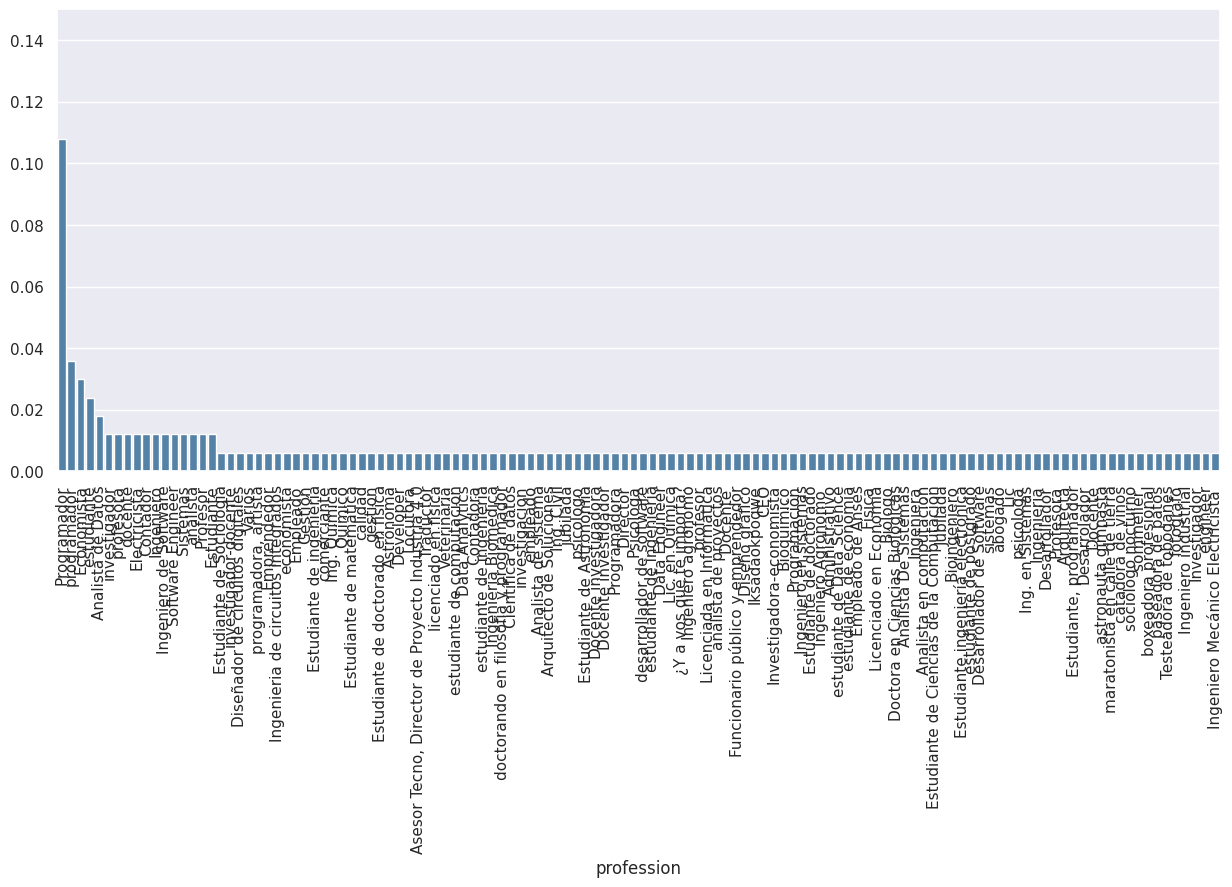

In [144]:
data = df.profession.value_counts(normalize=True)
plt.figure(figsize=(15, 6))
seaborn.barplot(x=data.index, y=data.values, color='steelblue')
plt.xticks(rotation=90)
plt.ylim(0, 0.15)

<Axes: xlabel='age'>

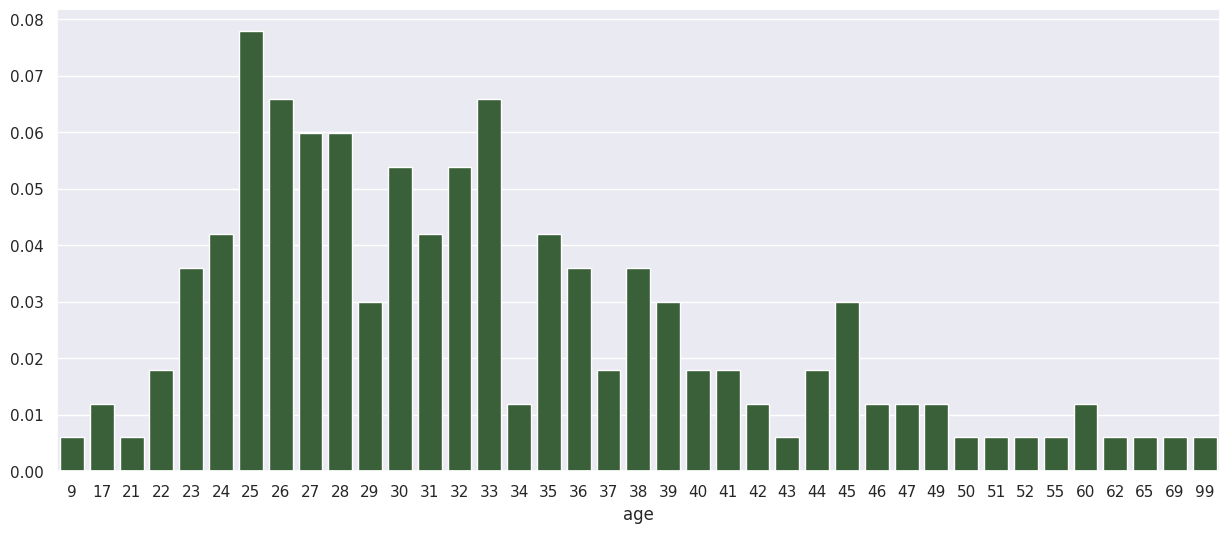

In [59]:
color = (0.2, # redness
         0.4, # greenness
         0.2, # blueness
         0.6 # transparency
         )
color2 = ['lightblue', 'blue', 'purple', 'red', 'black']
data = df.age.value_counts(normalize=True)
seaborn.color_palette("flare")
plt.figure(figsize=(15, 6))
seaborn.barplot(x=data.index, y=data.values,color=color)

En este gráfico, podemos pensar que todos los valores del rango de 9 a 99 estan representados y no es así.

### Lineplot

<Axes: xlabel='age'>

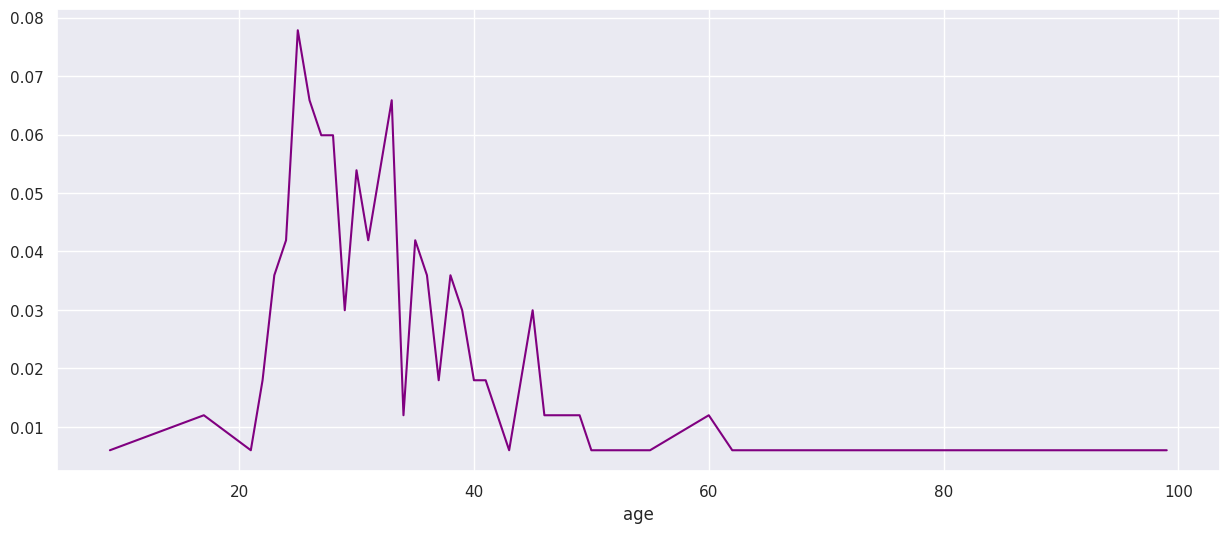

In [60]:
data = df.age.value_counts(normalize=True)
plt.figure(figsize=(15, 6))
seaborn.lineplot(x=data.index, y=data.values, color='purple')


En ambos gráficos, ¿están todos los valores representados? ¿qué sucedió con los valores faltantes? ¿Podríamos usar este tipo de gráfico si la variable pudiera tomar miles de valores posibles?








###Histograma

La forma más adecuada de representar esta infomación para variables numéricas es el histograma, que separa el rango completo de valores en contenedores (bins) ancho constante y cuenta cuántos ejemplos caen dentro de cada contenedor.



En muchos ejemplos de la web suele estar todavia el comando seaborn.displot pero ya ha sido reemplazado. Funciona pero chilla en agonía avisando que pronto no va a estar mas disponible.

/tmp/ipython-input-2969561803.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  seaborn.distplot(df.age, bins=15, kde=False, norm_hist=True, color ='red')


<Axes: xlabel='age'>

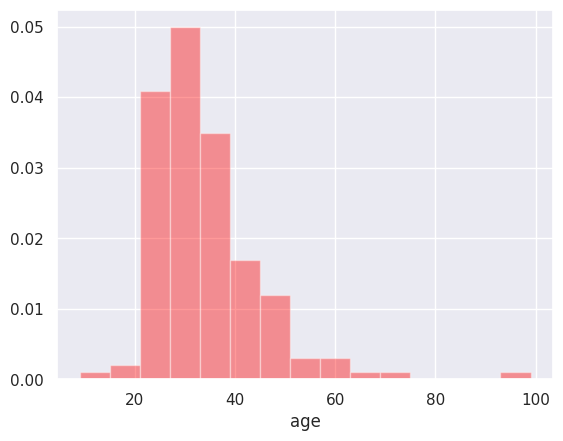

In [61]:
seaborn.distplot(df.age, bins=15, kde=False, norm_hist=True, color ='red')

La función seaborn.distplot has sido cambiada por la funcion seaborn.histplot. Para que muestre frecuencia y no conteo se le agrega la keyword stat="density": La nueva funcion produce un histograma bastante parecido al que realizaba distplot.

<Axes: xlabel='age', ylabel='Density'>

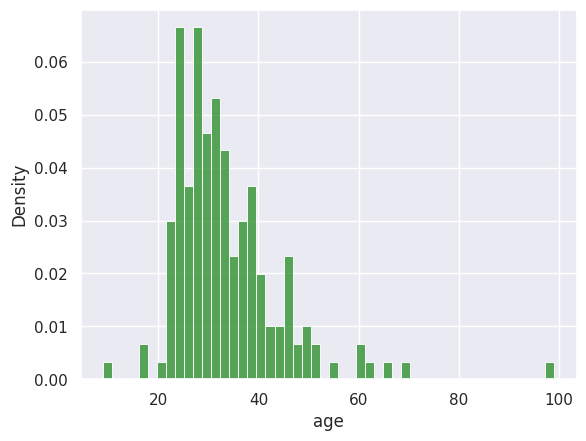

In [198]:
seaborn.histplot(df.age, bins=50, kde=False, stat="density",color='forestgreen')



Una forma todavía más fácil de hacer un histograma es usando pandas mismo, pero el control sobre los elementos gráficos es menor:

<Axes: >

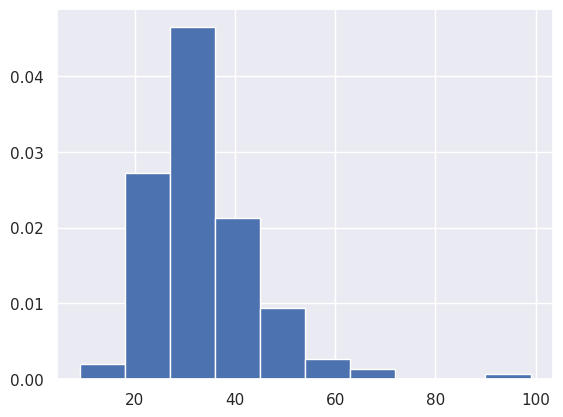

In [ ]:
df.age.hist(density=1)

##2.3 Función de densidad acumulada

Pandas permite graficar la FDA de cualquier columna numérica:

Usando pandas

<Axes: >

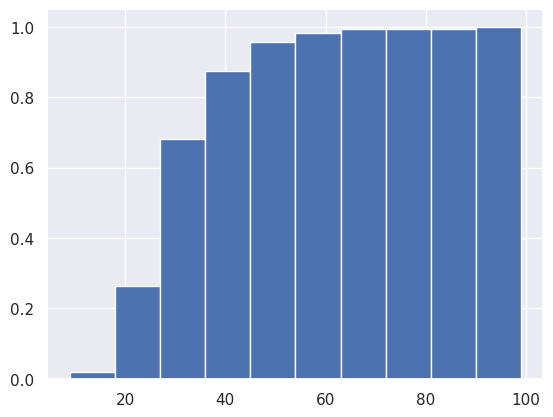

In [ ]:
## Función de densidad acumulada
df.age.hist(cumulative=True, density=1)

Usando seaborn

<Axes: xlabel='age', ylabel='Proportion'>

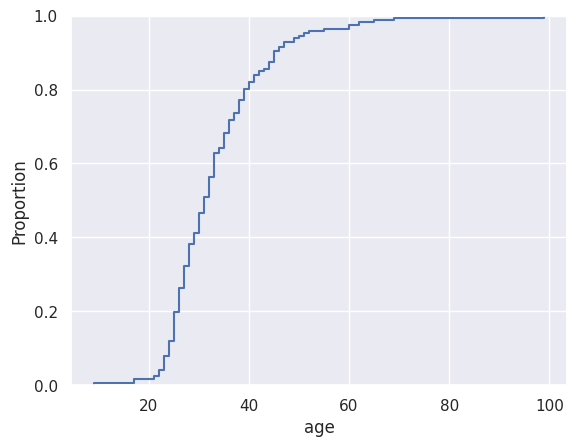

In [200]:
seaborn.ecdfplot(df, x="age")#, hue="gender")

## 2.4 Agrupaciones

Es muy útil poder comparar también más de una variable categórica a la vez. Para ello, podemos usar el atributo `hue` de los gráficos de barra.

En general, conviene agrupar por la variable que tengan menos categorías. Entonces, si queremos comparar las estimaciones de sueldo con respecto la profesión y el género, conviene agrupar por género, que sólo puede tener 4 variables posibles.

Notar:

- Son gráficos muy versátiles, pero no siempre son adecuados. Mientras más barras se grafican, menos atención se pone en la variación entre una barra y otra, y más evidente es la distribución total.

- Los gráficos de barra también son muy sensibles al ordenamiento, ya que mientras más alejadas están las barras más difícil es compararlas.

- Por otra parte, la diferencia en el tamaño de cada barra puede codificar sólo cierta cantidad de información.

 - Por ejemplo, si las barras son grandes en alto, una pequeña diferencia entre ellas pasará desapercibida, mientras que si las barras son pequeñas, la misma diferencia será más evidente.

- Los gráficos de barra son lo más adecuados para ver las variables categorícas, por ejemplo, el género.
- Además de eso, necesitamos seleccionar una variable aleatoria con datos numéricos para poder graficar en el eje y.

Tomemos la estimación del sueldo para juniors y veamos cómo se construye uno de estos gráficos:

Hagamos una copia de nuestro dataset

<Axes: xlabel='gender', ylabel='junior_programmer_salary'>

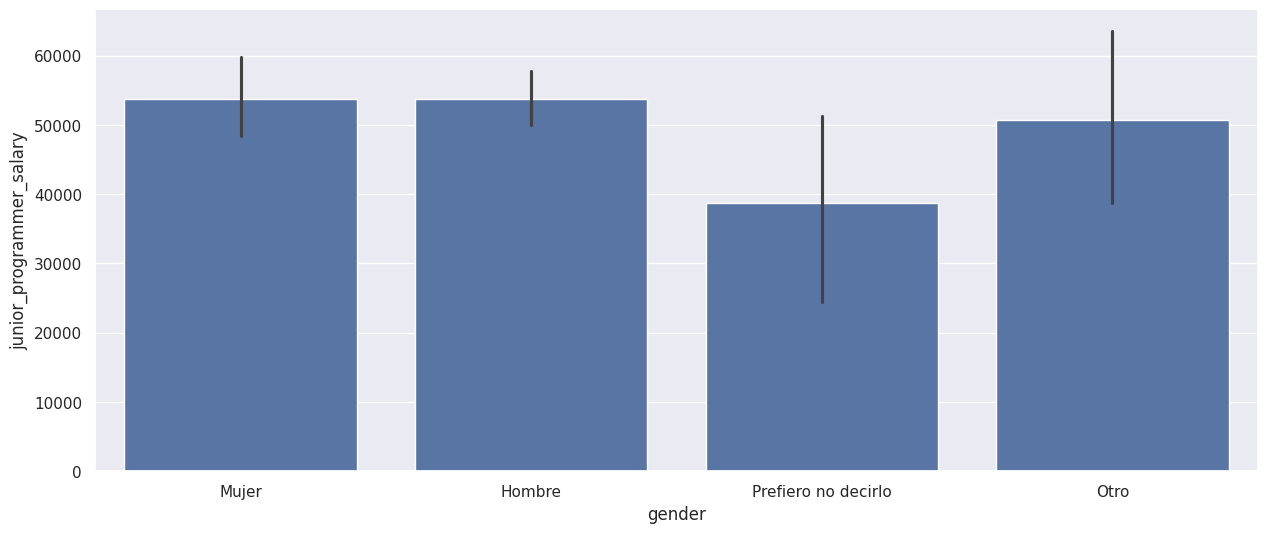

In [201]:
seaborn.set_theme(style="darkgrid")
plt.figure(figsize=(15, 6))
seaborn.barplot(data=df, x='gender', y='junior_programmer_salary')

- En este gráfico estamos usando la altura de las barras para representar el promedio de las estimaciones de salario para cada uno de los grupos.
Sin embargo, esto no es evidente a primera vista.

- El usuario no tiene suficiente información para inferir el significado del eje vertical. Hay que tener en cuenta que muchas veces, **el nombre original de la columna no representa la información agregada**.



- Por otra parte, ¿qué significan las líneas negras? Son los intervalos de confianza, que tienen un valor por default de 95.

- Indica que el verdadero valor poblacional del estadístico se encuentra en ese rango, con una confianza del 95%.

- Por eso vemos que (probablemente) para varones y mujeres, el rango es mucho más pequeño, ya que la muestra es mucho más grande.

- Para otros grupo minoritario, no tenemos certeza del valor real de la media poblacional porque la muestra es demasiado pequeña.



- Este estadístico suele ser difícil de interpretar para quienes no son expertos en estadística, puede ser conveniente reemplazarlo por la desviación estándar de la muestra.

 - Si bien estamos usando la misma codificación visual (las rayitas negras), los valores que representamos son completamente distintos.

 - Si usamos un intervalo de confianza, estamos hablando de la distribución del estimador de la media poblacional, que es una variable aleatorio que toma valores en todas las muestras posibles.

 - Por otro lado, si usamos la desviación estándar, estamos hablando del valor del estadístico en esta muestra.

Con esas observaciones, podemos construir un gráfico más representativo.

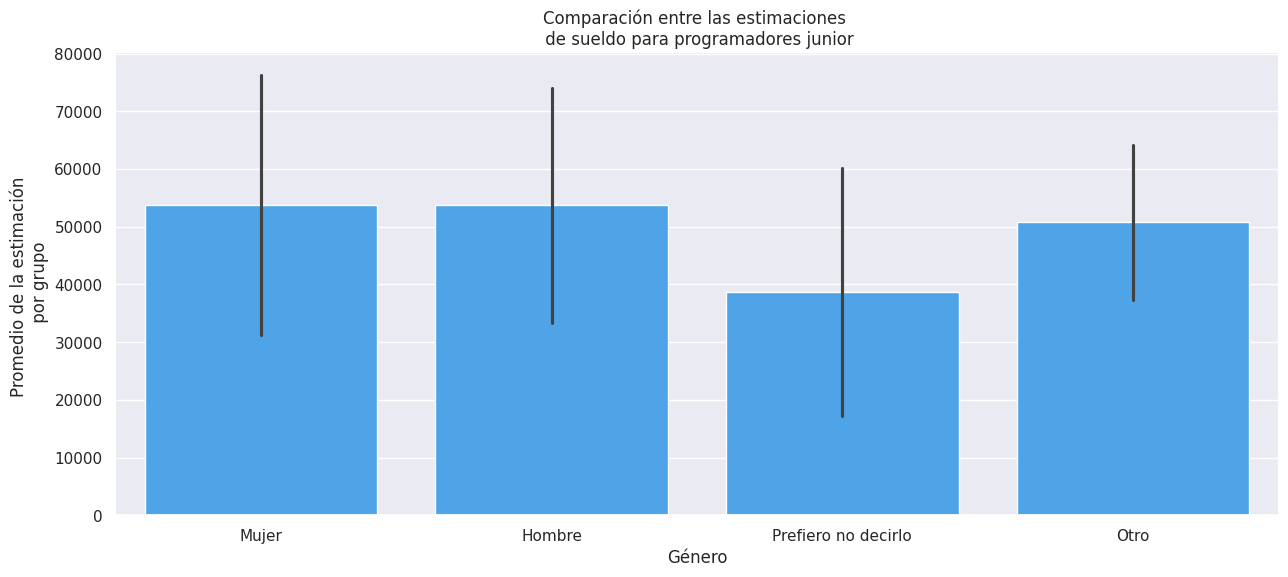

In [154]:
plt.figure(figsize=(15,6))
seaborn.barplot(data=df, x='gender', y='junior_programmer_salary',
                color=BLUE, errorbar='sd')
plt.ylabel('Promedio de la estimación \n por grupo')
plt.xlabel('Género')
plt.title('Comparación entre las estimaciones \n de sueldo para programadores junior')
seaborn.despine(left=True)

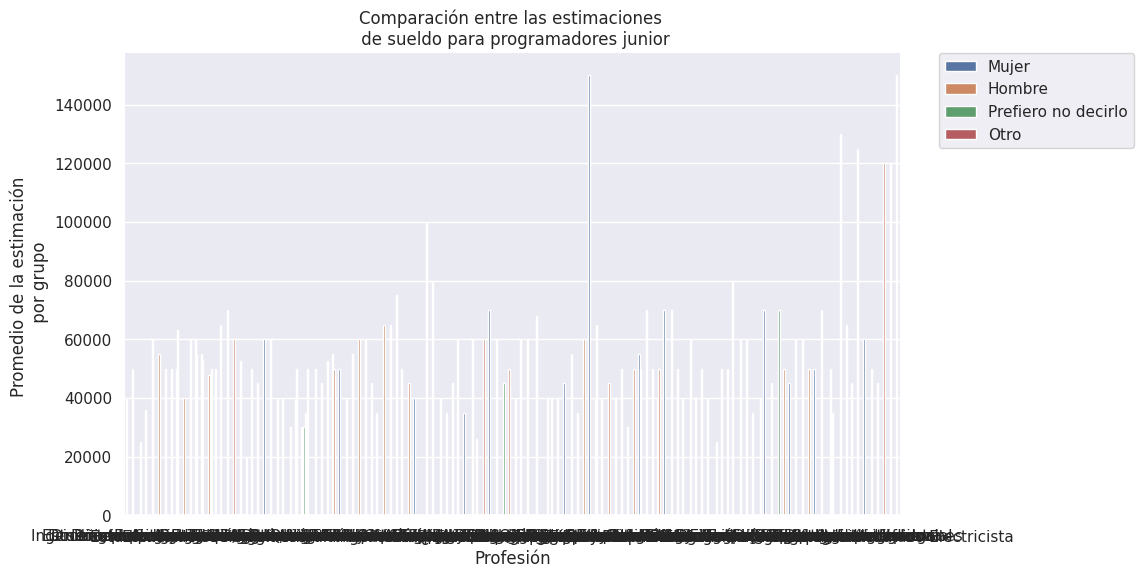

In [203]:
plt.figure(figsize=(10,6))
seaborn.barplot(data=df, x='profession', y='junior_programmer_salary',
                hue='gender', errorbar=None)
plt.ylabel('Promedio de la estimación \n por grupo')
plt.xlabel('Profesión')
plt.title('Comparación entre las estimaciones \n de sueldo para programadores junior')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
seaborn.despine(left=True)

¡El primer gráfico nos queda un desastre! Esto ocurre porque:
1. No podemos leer las etiquetas del eje x. Por suerte, esto es muy fácil de solucionar agregando `plt.xticks(rotation=90)`
1. La cantidad de valores para el campo profesión son demasiadas para un gráfico. Esto es solucionable: o bien manualmente agrupamos las categorías en valores estándar, o nos limitamos sólo a graficar las categorías con más datos.
1. No tenemos suficientes puntos para generar columnas para todas las combinaciones. Esta limitación es más difícil de solucionar, y puede indicarnos que este no es el método adecuado para representar esta información.
4. ¿Se les ocurren más?

Tratemos entonces con un gráfico que sí tenga sentido: dada la cantidad de respuestas, esperamos tener suficientes ejemplos para los dos géneros más populares y para casi todos los signos del zodiaco (a pesar de que no saquemos ninguna información útil de graficar esto).

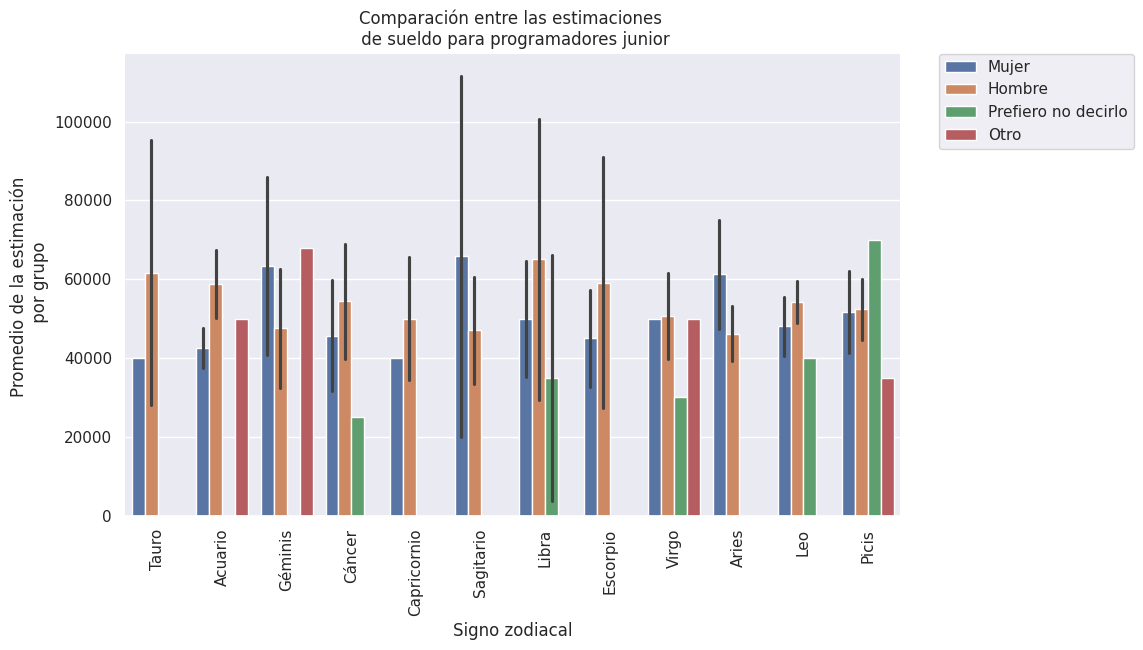

In [156]:
plt.figure(figsize=(10,6))
seaborn.barplot(data=df, x='zodiac_sign', y='junior_programmer_salary',
                hue='gender', errorbar='sd')
plt.ylabel('Promedio de la estimación \n por grupo')
plt.xlabel('Signo zodiacal')
plt.title('Comparación entre las estimaciones \n de sueldo para programadores junior')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
seaborn.despine(left=True)

## 2.5. Histogramas

Muestra la distribución de una variable numérica, dividiendo las variables en segmentos (*bins*) o estimando una función de densidad. Ojo, ¡no es lo mismo que un gráfico de barras!

Por ejemplo, podemos graficar con más precisión la distribución de la variable *junior_programmer_salary*.

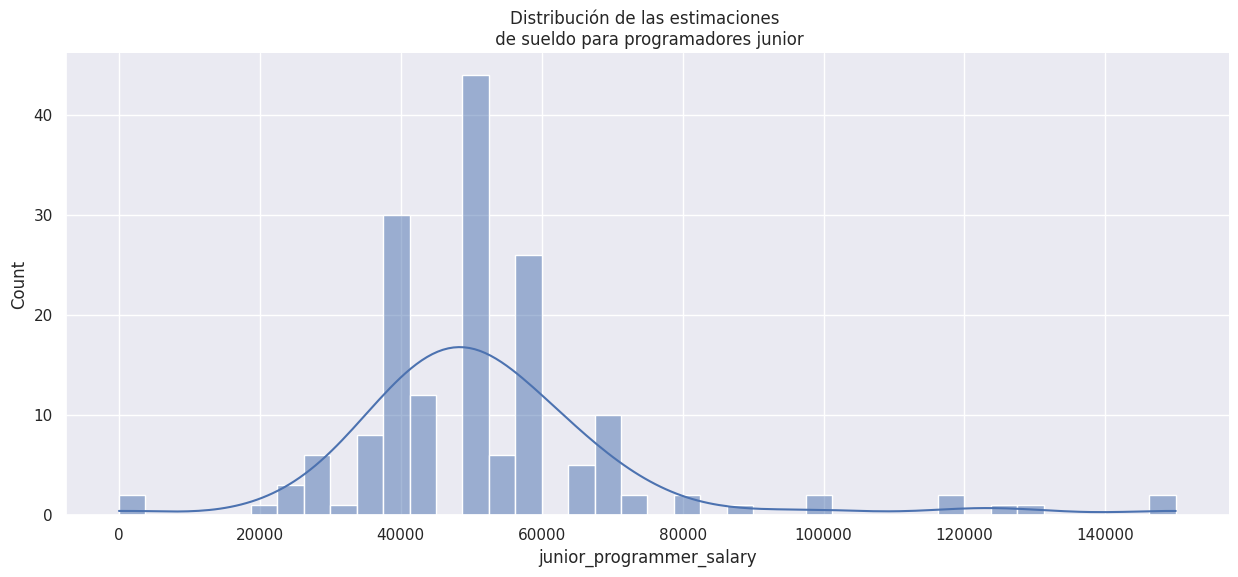

In [69]:
plt.figure(figsize=(15,6))
plt.title('Distribución de las estimaciones \n de sueldo para programadores junior')
seaborn.histplot(df.junior_programmer_salary.dropna(), kde=True, bins=40)
seaborn.despine()

### Outliers

Es muy probable que encontremos outliers en nuestro dataset que complican la visualización.

Una forma de calcular los outliers es con los percentiles o dejando sólo los que se encuentran en un rango de X desviaciones estándares de la media.

In [157]:
def clean_outliers(dataset, column_name):
    """Returns dataset removing the outlier rows from column @column_name."""
    interesting_col = dataset[column_name]
    # Here we can remove the outliers from both ends, or even add more restrictions.
    mask_salarios_outlier = (
        numpy.abs(interesting_col - interesting_col.mean()) <= (2.5 * interesting_col.std()))
    return dataset[mask_salarios_outlier]



In [205]:
data_junior = clean_outliers(df, "junior_programmer_salary").junior_programmer_salary
print("Filas removidas", len(df) - len(data_junior))
print("Salario máximo considerado", data_junior.max())

Filas removidas 8
Salario máximo considerado 100000


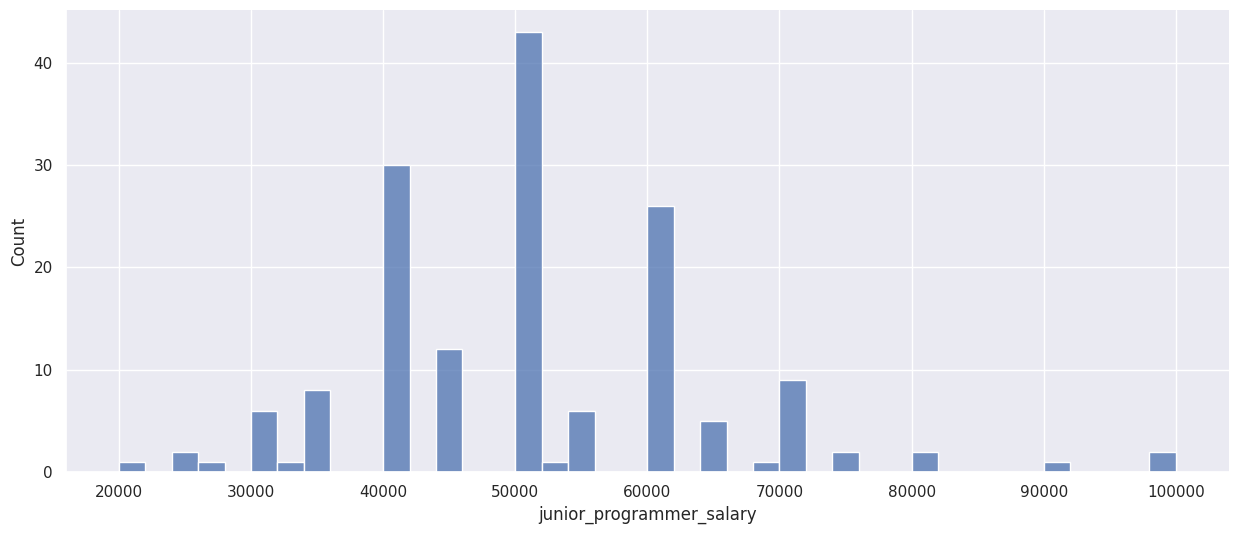

In [206]:
plt.figure(figsize=(15,6))
seaborn.histplot(data_junior, bins=40)
seaborn.despine()

### Múltiples histogramas

¡Podemos finalmente comparar las distribuciones de los salarios para seniors y para juniors! Graficaremos dos histogramas, uno por encima del otro.

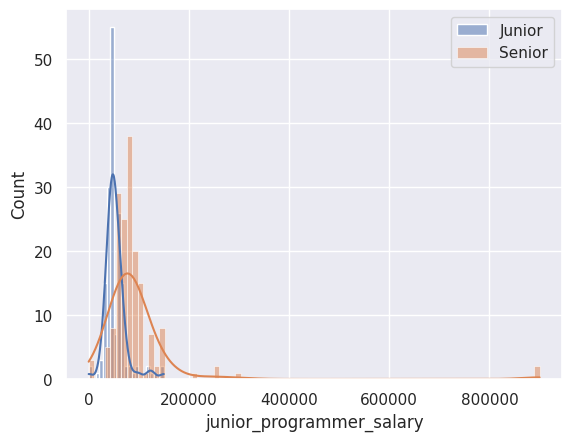

In [207]:
seaborn.histplot(
    df.junior_programmer_salary, label='Junior',kde='True')
seaborn.histplot(
    df.senior_programmer_salary, label='Senior',kde='True')
plt.legend()

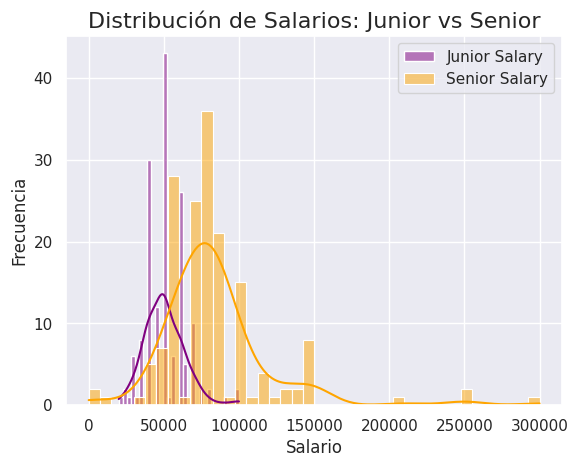

In [208]:
data_jr = clean_outliers(dataset, "junior_programmer_salary").junior_programmer_salary
seaborn.histplot(
    data_jr,
    label='Junior Salary',
    kde=True,
    color='purple',
    bins=30,
)

data_sr = clean_outliers(dataset, "senior_programmer_salary").senior_programmer_salary
seaborn.histplot(
    data_sr,
    label='Senior Salary',
    kde=True,
    color='orange',
    bins=40,
)

plt.title("Distribución de Salarios: Junior vs Senior", fontsize=16)
plt.xlabel("Salario", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)

plt.legend(title="Nivel de Experiencia", fontsize=10)
plt.legend()

Con la siguiente función podemos limpiar el gráfico anterior  remover los outliers, experimentar con distintos valores para el parámetro `bins`.

In [209]:
def to_categorical(column, bin_size=5, min_cut=15, max_cut=50):
    if min_cut is None:
        min_cut = int(round(column.min())) - 1
    value_max = int(numpy.ceil(column.max()))
    max_cut = min(max_cut, value_max)
    intervals = [(x, x + bin_size) for x in range(min_cut, max_cut, bin_size)]
    if max_cut != value_max:
        intervals.append((max_cut, value_max))
    print(intervals)
    return pandas.cut(column, pandas.IntervalIndex.from_tuples(intervals))

[(15, 20), (20, 25), (25, 30), (30, 35), (35, 40), (40, 45), (45, 50), (50, 99)]


(array([ 0., 10., 20., 30., 40., 50.]),
 [Text(0.0, 0, '0'),
  Text(10.0, 0, '10'),
  Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50')])

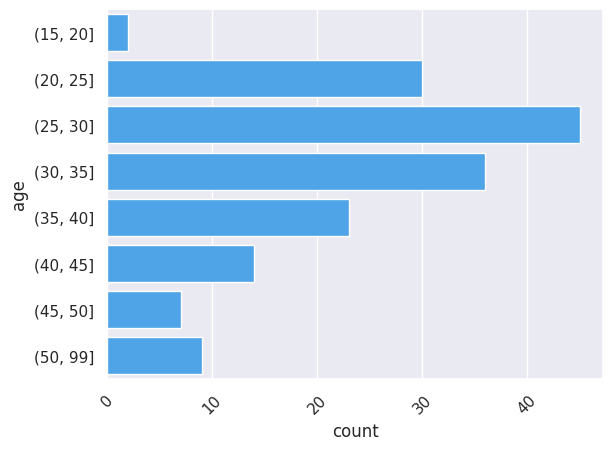

In [210]:
seaborn.countplot(to_categorical(df.age.dropna()), color=BLUE)
plt.xticks(rotation=45)


## 2.6 Gráficos de caja

Muestra la distribución de una variable numérica, de una forma más condensada que un histograma. Son muy útiles para comparar muchas distribuciones, pero sólo cuando son muy distintas entre ellas, ya que oscurecen algunas sutilezas. Otros problema de este tipo de gráficos es que *no todo el mundo recuerda cómo leerlos*.

Por ejemplo, volvamos al ejemplo anterior para comparar la distribución de las estimaciones para el salario de un junior. Con un gráfico de caja, se vería de la siguiente manera:

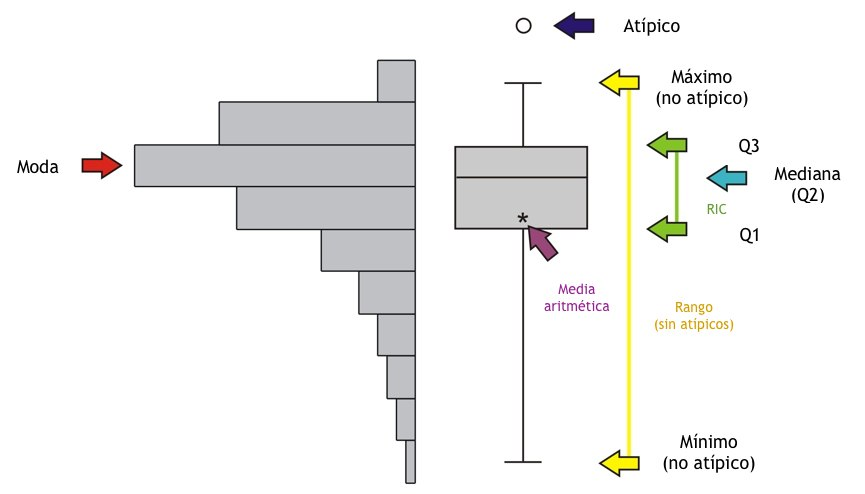

In [211]:
print('MEDIDAS DE POSICIÓN:')
media = df.junior_programmer_salary.mean()
print('media =', media)
print('mediana =', df.junior_programmer_salary.median())

Q_1 = df.junior_programmer_salary.quantile(0.25) #primer cuartil
print('Q_1=', Q_1)

print('Q_2 o mediana=', df.junior_programmer_salary.quantile(0.5)) #otra forma de calcular la mediana

Q_3 = df.junior_programmer_salary.quantile(0.75) #tercer cuartil
print('Q_3=', Q_3)

print('--------------')
print('MEDIDAS DE DISPERSIÓN:')
print('Rango=(max-min)=', df.junior_programmer_salary.max()-df.junior_programmer_salary.min())


desviacion = df.junior_programmer_salary.std() #desviación estandar
print('Desviación poblacional=', desviacion)

print('Varianza poblacional=', df.junior_programmer_salary.var())

RIC = Q_3-Q_1 #rango intercuartil
print('RIC=', RIC)

CV = round((desviacion / media) * 100, 2) #redondea 2 decimales
print('CV=', CV, '%')

MEDIDAS DE POSICIÓN:
media = 52922.5628742515
mediana = 50000.0
Q_1= 40000.0
Q_2 o mediana= 50000.0
Q_3= 60000.0
--------------
MEDIDAS DE DISPERSIÓN:
Rango=(max-min)= 149997
Desviación poblacional= 21027.06156778068
Varianza poblacional= 442137318.1752394
RIC= 20000.0
CV= 39.73 %


In [173]:

junior_programmer_data = clean_outliers(df, "junior_programmer_salary")
junior_programmer_data = junior_programmer_data[~junior_programmer_data.age.isnull()]
junior_programmer_data['age_segment'] = to_categorical(junior_programmer_data.age)



[(15, 20), (20, 25), (25, 30), (30, 35), (35, 40), (40, 45), (45, 50), (50, 99)]


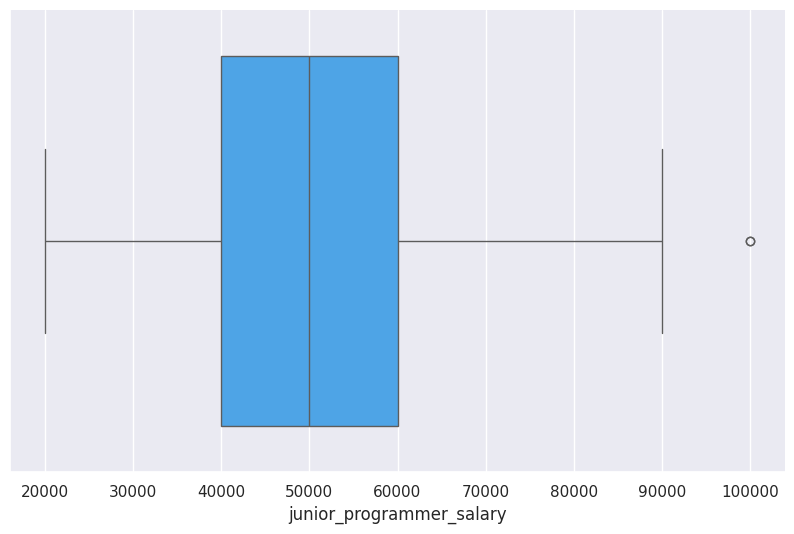

In [212]:
plt.figure(figsize=(10,6))
seaborn.boxplot(data=junior_programmer_data,
                 x='junior_programmer_salary',
                color=BLUE)


seaborn.despine()

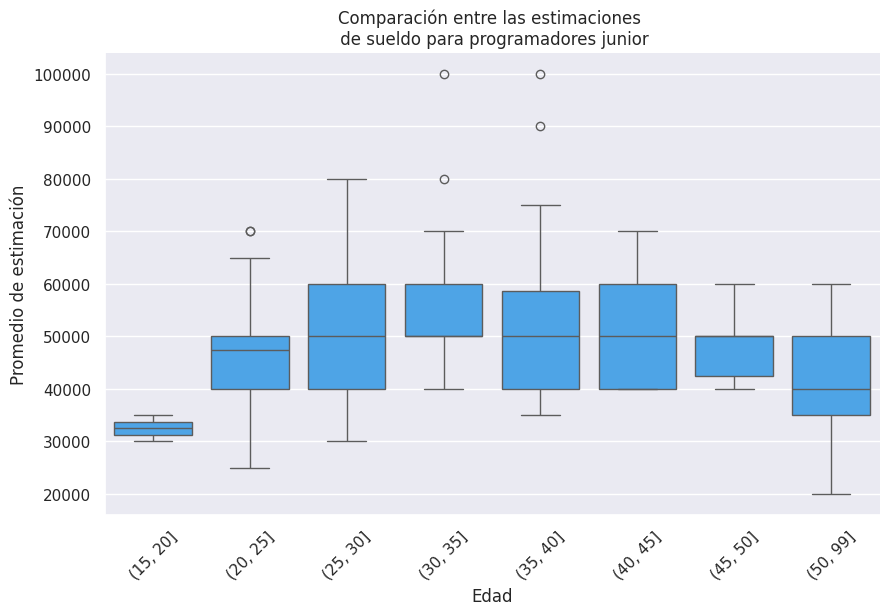

In [213]:
plt.figure(figsize=(10,6))
seaborn.boxplot(data=junior_programmer_data,
                x='age_segment', y='junior_programmer_salary',
                color=BLUE)
plt.ylabel('Promedio de estimación')
plt.xlabel('Edad')
plt.title('Comparación entre las estimaciones \n de sueldo para programadores junior')
plt.xticks(rotation=45)
seaborn.despine()

Con los boxplot también podemos comparar distribuciones por grupos. En este caso, si un grupo tiene una población muy reducida, su influencia visual es mucho menor ya que se traducen a cajas pequeñas o incluso sólo puntos.

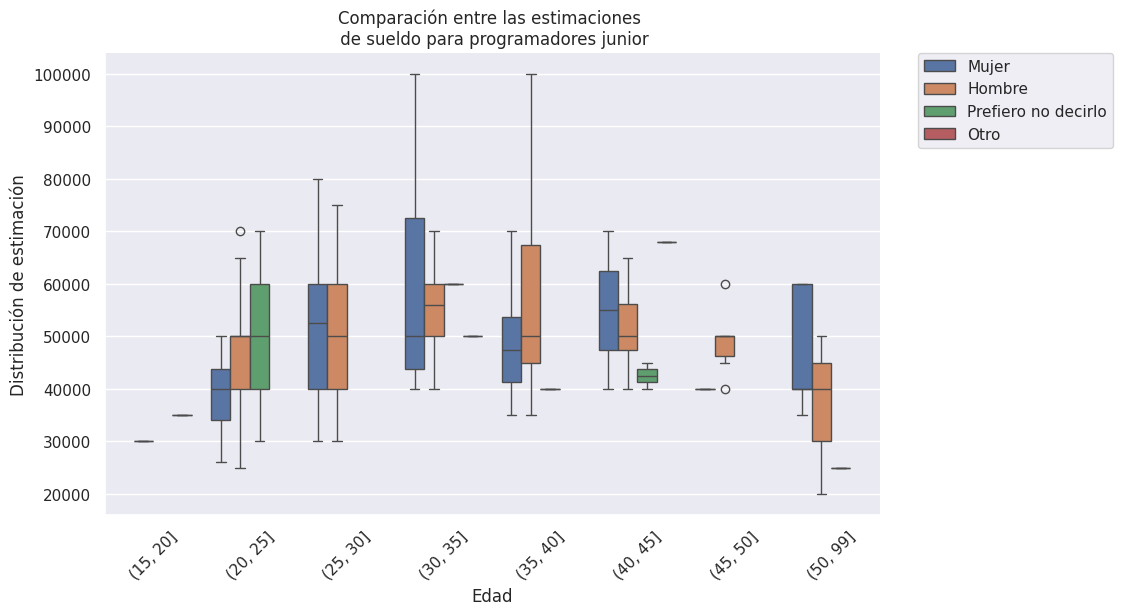

In [176]:
plt.figure(figsize=(10,6))
seaborn.boxplot(data=junior_programmer_data,
                x='age_segment', y='junior_programmer_salary',
                hue='gender')
plt.ylabel('Distribución de estimación')
plt.xlabel('Edad')
plt.title('Comparación entre las estimaciones \n de sueldo para programadores junior')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
seaborn.despine()

En este gráfico podemos ver, por ejemplo, todos los outliers con sueldos mayores a 100,000, que en el otro gráfico se agrupaban dentro de la barra de desviación estándar.

## 2.7 Gráficos de puntos (scatterplot)

Muestra la relación entre 2 o 3 variables numéricas continuas. Adicionalmente, se puede usar el color y la forma de los puntos para variables categóricas, y el tamaño para una variable numérica extra.

Para poder ejemplificar el gráfico de puntos, debemos encontrar dos variables numéricas continuas. Tener en cuenta que por más que una variable sea discreta, al incluirla en un scatter plot la estamos tratando como una variable continua.

<Axes: xlabel='age', ylabel='junior_programmer_salary'>

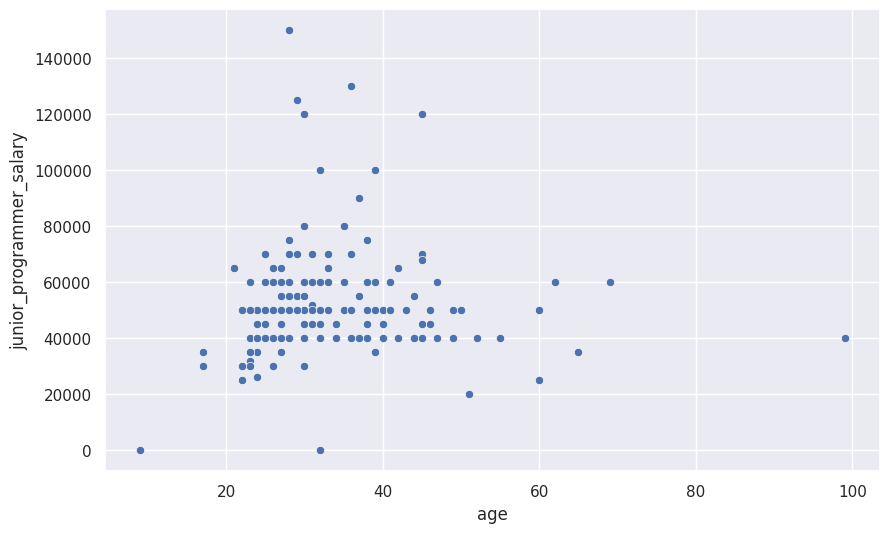

In [170]:
plt.figure(figsize=(10,6))
seaborn.scatterplot(data=df,
                    x='age',
                    y='junior_programmer_salary')

Para hacer más evidente las tendencias que pueda tener el gráfico, podemos utilizar seaborn para estimar una regresión lineal con los datos, utilizando el gráfico seaborn.regplot. Sin embargo, existen maneras más efectivas de medir correlación, gráficas y analíticas, que veremos más adelante.

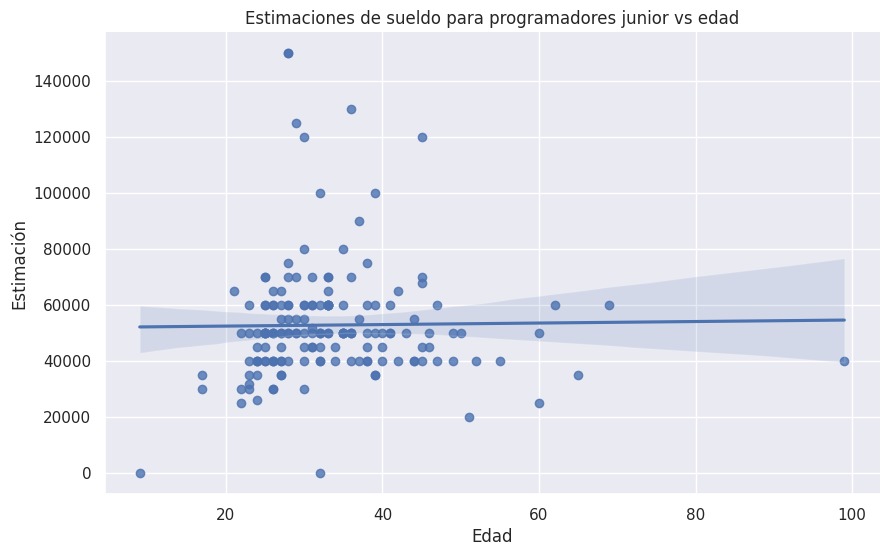

In [171]:
plt.figure(figsize=(10,6))
seaborn.regplot(data=df, x='age',
                y='junior_programmer_salary')
plt.ylabel('Estimación')
plt.xlabel('Edad')
plt.title('Estimaciones de sueldo para programadores junior vs edad')
seaborn.despine()

## 2.8 Heatmaps

Los heatmaps se utilizan para codificar la relación entre dos variables categóricas o discretas (o discretizadas). Si alguna de las variables es numérica, se puede discretizar o utilizar otro tipo de gráfico como `regplot`,  `pairplot` o `catplot`.

Por ejemplo, una pregunta posible podría ser **¿Nuestra muestra, está uniformente distribuida en cuando a género y edad?**.

In [179]:
def to_categorical(column, bin_size=5, min_cut=15, max_cut=50):
    if min_cut is None:
        min_cut = int(round(column.min())) - 1
    value_max = int(numpy.ceil(column.max()))
    max_cut = min(max_cut, value_max)
    intervals = [(x, x + bin_size) for x in range(min_cut, max_cut, bin_size)]
    if max_cut != value_max:
        intervals.append((max_cut, value_max))
    print(intervals)
    return pandas.cut(column, pandas.IntervalIndex.from_tuples(intervals))

In [180]:
plt.figure(figsize=(10,8))
df = df[~df.age.isnull()]
df['age_segment'] = to_categorical(df.age)

[(15, 20), (20, 25), (25, 30), (30, 35), (35, 40), (40, 45), (45, 50), (50, 99)]


<Figure size 1000x800 with 0 Axes>

En este tipo de situaciones con pocas categorías es ideal usar un heatmap. Sin embargo, no es tan intuitivo de hacer porque tenemos que pasar como argumento la matriz de co-ocurrencias ya previamente armada. Les recomendamos leer cómo funciona el comando `pandas.crosstab` para entender cómo funciona el siguiente código, aunque existen otras formas como `pivot`.

<Axes: xlabel='age_segment', ylabel='gender'>

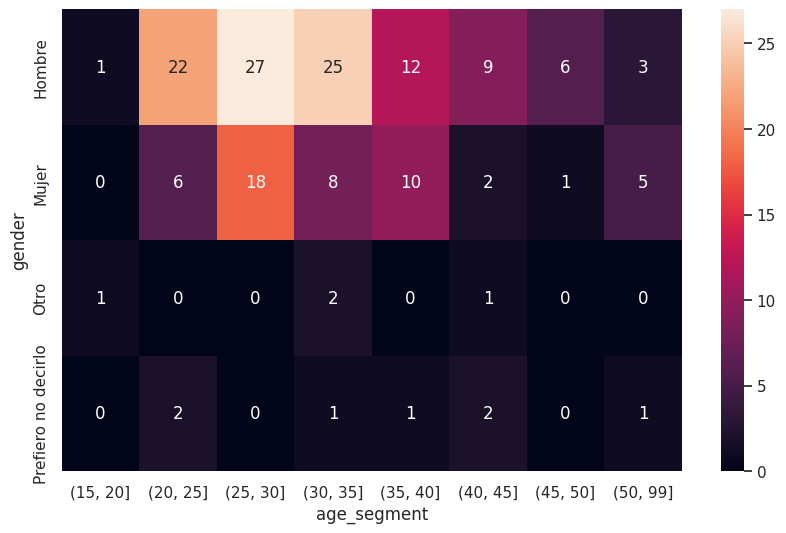

In [181]:
plt.figure(figsize=(10,6))
exp = pandas.crosstab(df.gender, df.age_segment)
seaborn.heatmap(exp, annot=True)

## 2.8 Jointplots

En caso de que querramos estimar la correlación entre variables que sean numéricas, también se puede usar el `seaborn.jointplot`, pero no siempre logra un resultado interpretable.

Volvamos al ejemplo de la estimación de salarios con respecto a la edad de la persona. Haremos un jointplot con *kind=ked* y *kind=hex*. Con ambos gráficos podemos ver mejor las distribuciones que con el regplot, ya que los puntos individuales son agregados en una función de calor. Sin embargo, sucede lo mismo que con los heatmaps: no podemos asegurar que la concentración de valores conjuntos no sea sólo producto de los valores más frecuentes de cada distribución independiente.

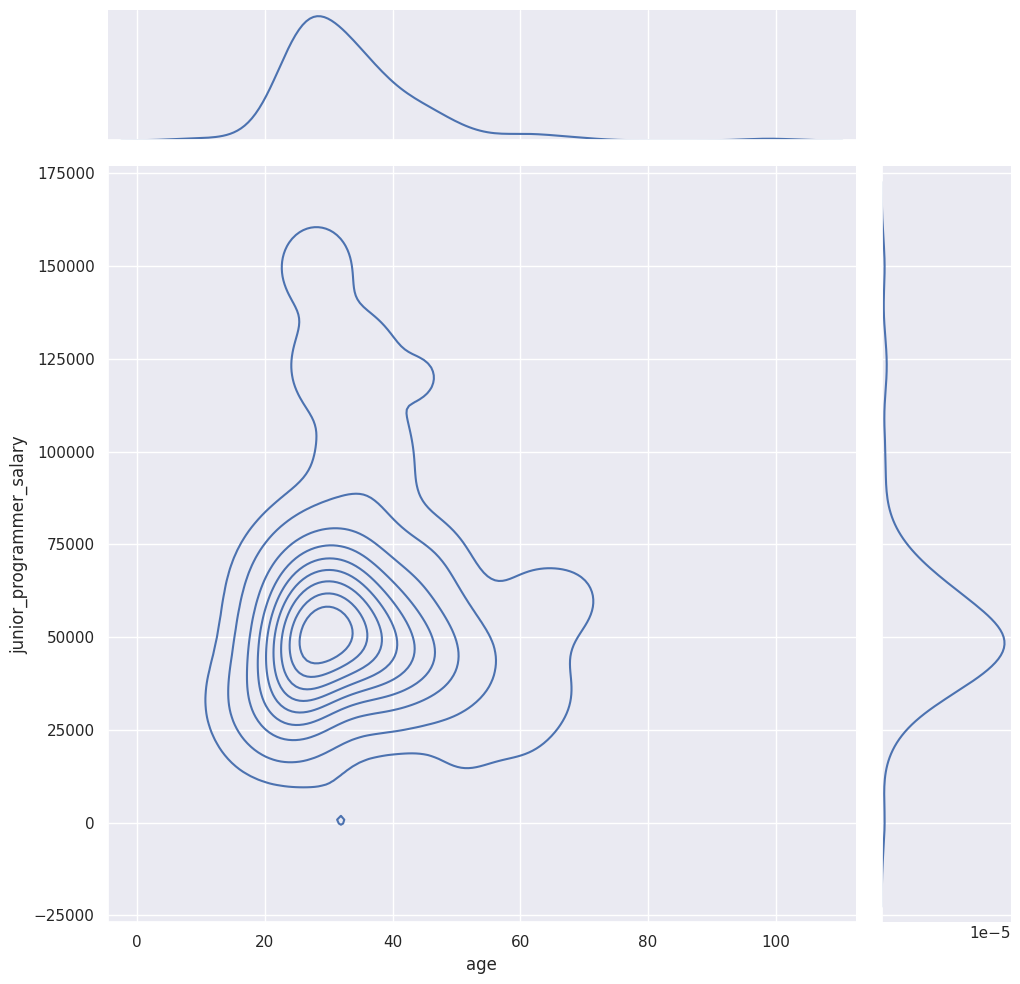

In [182]:
seaborn.jointplot(data=df, x='age',
                  y='junior_programmer_salary', kind='kde', height=10)

<Figure size 1500x600 with 0 Axes>

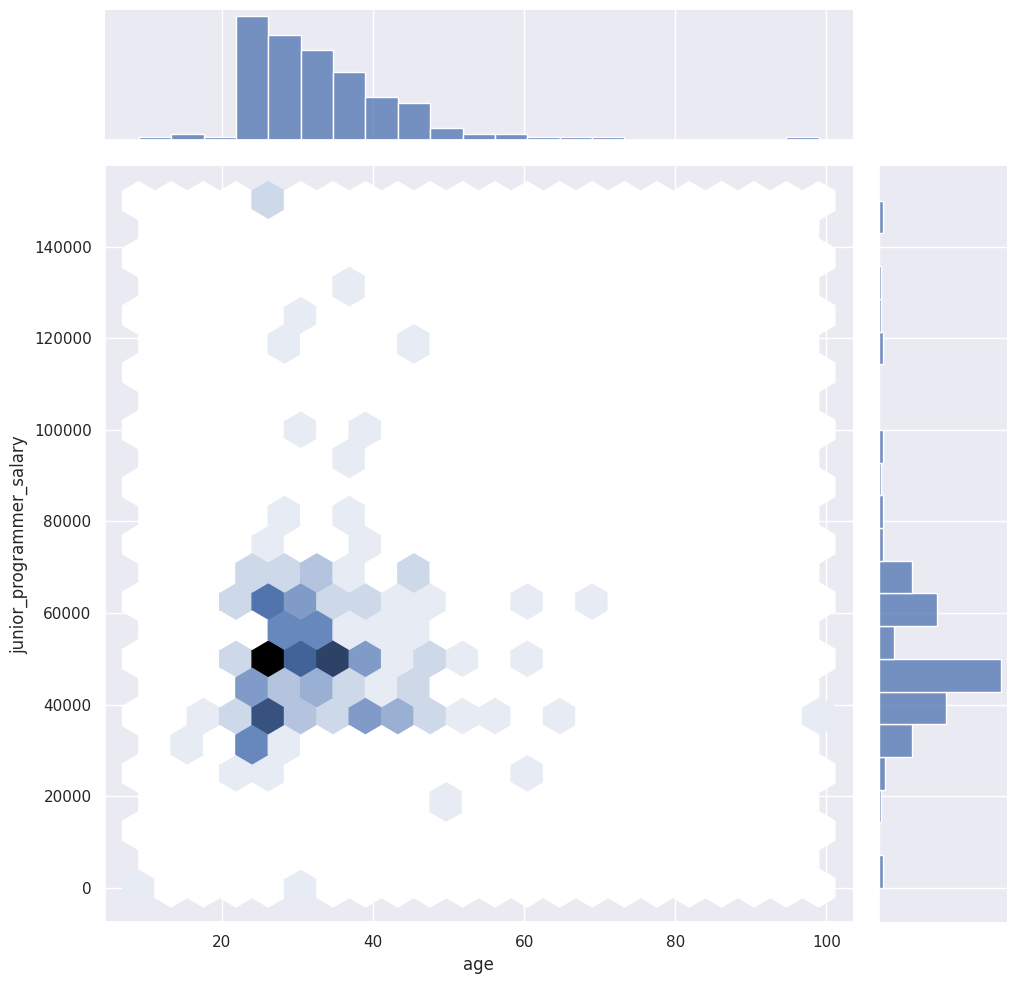

In [183]:
fig = plt.figure(figsize=(15,6))
seaborn.jointplot(data=df, x='age',
                  y='junior_programmer_salary', kind='hex', height=10)

## 2.9 Pairplots

Los pairplots son muy útiles para comparar muchas variables numéricas al mismo tiempo. Por ejemplo, se puede hacer una comparación entre la edad y ambas estimaciones de sueldo.

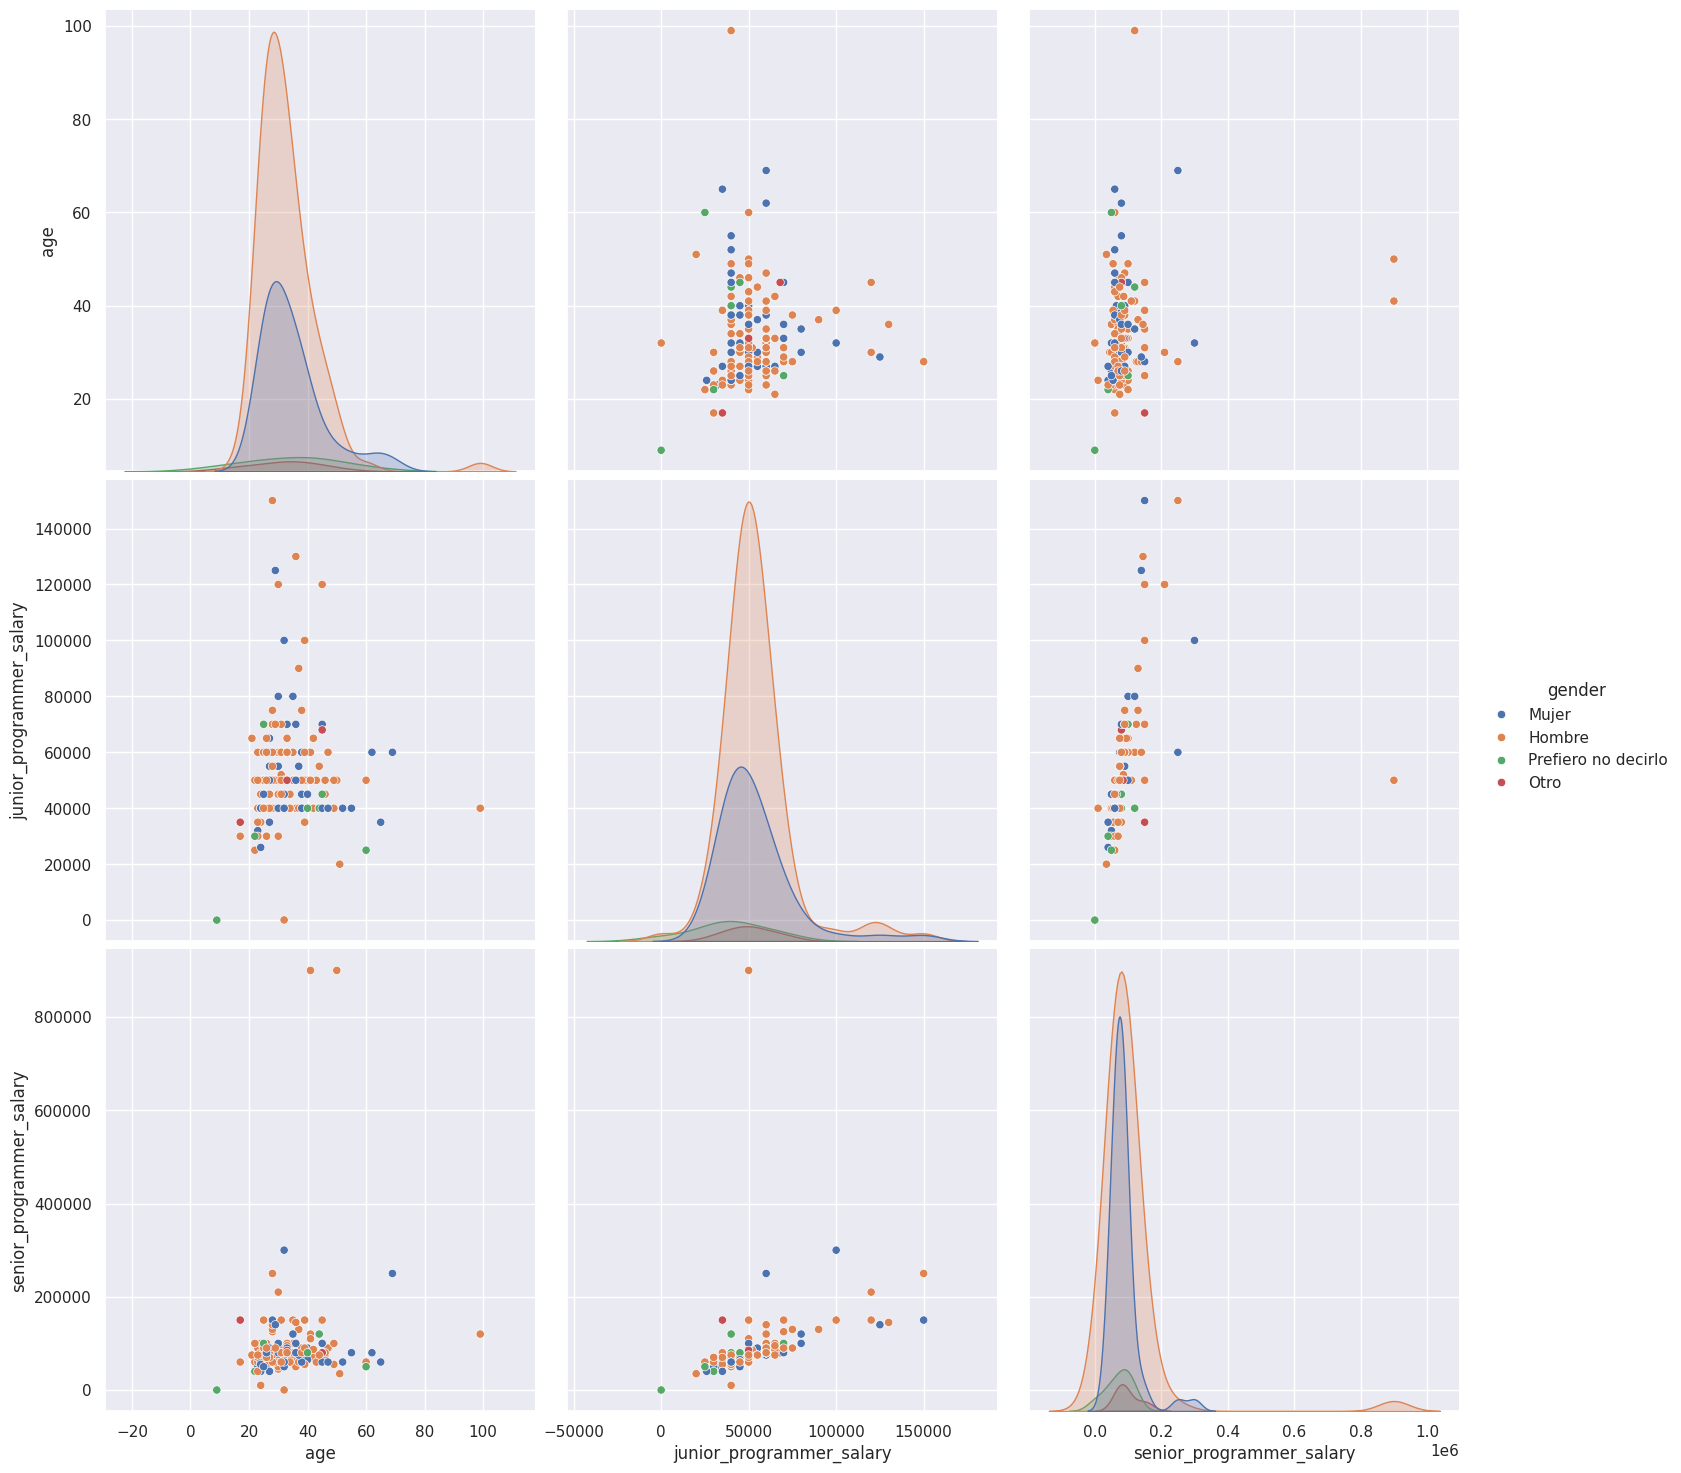

In [184]:
## TODO: maybe remove outliers
seaborn.pairplot(
    data=df,
    vars=['age', 'junior_programmer_salary', 'senior_programmer_salary'],
    hue='gender', height=5)